# REZ wind drought duration distribution, ERA5 vs BARRA-RE2

This notebook updates the original REZ duration analysis by adding **BARRA-RE2** comparison on the same bar graph.

Important handling for BARRA-RE2:

- BARRA-RE2 yearly drought mask files have 22 realizations.
- Event durations are calculated separately for each realization and REZ grid cell.
- The BARRA-RE2 duration distribution is then pooled across all 22 realizations.
- This is the correct way to compare duration distributions, because an ensemble mean mask is no longer binary and cannot be used directly for event-duration extraction.


In [1]:
import os
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [2]:
# =====================
# Paths
# =====================
era5_wd_dir = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"

barra_wd_dir = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly"

rez_file = "/g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc"

output_dir = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis"
os.makedirs(output_dir, exist_ok=True)

start_year = 1990
end_year = 2025

lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

print("ERA5 directory :", era5_wd_dir)
print("BARRA directory:", barra_wd_dir)
print("Output directory:", output_dir)


ERA5 directory : /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5
BARRA directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly
Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis


In [3]:
# =====================
# Helper functions
# =====================
def standardise_lon_lat_names(da):
    """Rename latitude/longitude to lat/lon if needed."""
    rename = {}

    if "longitude" in da.dims:
        rename["longitude"] = "lon"
    if "latitude" in da.dims:
        rename["latitude"] = "lat"

    if "longitude" in da.coords:
        rename["longitude"] = "lon"
    if "latitude" in da.coords:
        rename["latitude"] = "lat"

    if len(rename) > 0:
        da = da.rename(rename)

    return da


def get_first_data_var(ds, preferred="wind_drought"):
    """Return preferred variable if present, otherwise first data variable."""
    if preferred in ds.data_vars:
        return preferred
    return list(ds.data_vars)[0]


def event_durations_1d(mask):
    """
    Return durations of consecutive 1-runs in a 1D binary mask.
    The mask should already be the final 3-day drought mask.
    """
    mask = np.asarray(mask, dtype=np.int8)

    padded = np.pad(
        mask,
        (1, 1),
        mode="constant",
        constant_values=0
    )

    changes = np.diff(padded)

    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    durations = ends - starts

    return durations.tolist()


def files_for_years(input_dir):
    files = sorted(glob(os.path.join(input_dir, "wind_drought_P20_3day_*.nc")))

    selected = []
    for fp in files:
        year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
        if start_year <= year <= end_year:
            selected.append(fp)

    return selected


def summarize_durations(name, durations):
    durations = np.asarray(durations)

    summary = {
        "dataset": name,
        "number_of_events": int(len(durations)),
        "mean_duration_days": float(np.mean(durations)),
        "median_duration_days": float(np.median(durations)),
        "p95_duration_days": float(np.percentile(durations, 95)),
        "max_duration_days": int(np.max(durations)),
    }

    return summary


In [4]:
# =====================
# Load REZ mask
# =====================
rez_ds = xr.open_dataset(rez_file, engine="netcdf4")

if "rez_mask" in rez_ds.data_vars:
    rez = rez_ds["rez_mask"].squeeze()
else:
    rez = rez_ds[list(rez_ds.data_vars)[0]].squeeze()

rez = standardise_lon_lat_names(rez)

# Remove any non-spatial singleton dimensions
for d in list(rez.dims):
    if d not in ["lat", "lon"]:
        if rez.sizes[d] == 1:
            rez = rez.isel({d: 0}, drop=True)
        else:
            raise ValueError(f"Unexpected non-spatial REZ dimension: {d}")

# Sort for safe interpolation
if "lat" in rez.coords:
    rez = rez.sortby("lat")
if "lon" in rez.coords:
    rez = rez.sortby("lon")

rez_valid = np.isfinite(rez)

print(rez)
print("REZ valid cells:", int(rez_valid.sum().values))


<xarray.DataArray 'rez_mask' (lat: 139, lon: 178)> Size: 198kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(139, 178))
Coordinates:
  * lon      (lon) float32 712B 112.0 112.2 112.5 112.8 ... 155.8 156.0 156.2
  * lat      (lat) float32 556B -44.5 -44.25 -44.0 -43.75 ... -10.5 -10.25 -10.0
Attributes:
    standard_name:  region
    long_name:      REZ region ID
    units:          region number
    description:    Renewable Energy Zone (REZ) mask at ERA5 0.25x0.25 deg grid
    note:           Based on the REZs available at: https://aemo.com.au/-/med...
REZ valid cells: 1269


In [5]:
# =====================
# Collect ERA5 event durations in REZ cells
# =====================
era5_files = files_for_years(era5_wd_dir)

print("ERA5 files:", len(era5_files))
print("First ERA5:", era5_files[0])
print("Last ERA5 :", era5_files[-1])

era5_durations = []

# Flattened REZ-valid cells on ERA5 grid
rez_valid_era5 = rez_valid.transpose("lat", "lon")
valid_flat_era5 = rez_valid_era5.values.reshape(-1)

for fp in tqdm(era5_files, desc="ERA5 years", unit="year"):

    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    print(f"Processing ERA5 {year}", flush=True)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    var_name = get_first_data_var(ds, preferred="wind_drought")

    wd = standardise_lon_lat_names(ds[var_name])

    # Match ERA5 drought grid to REZ grid
    wd = wd.sel(
        lat=rez["lat"],
        lon=rez["lon"]
    )

    wd = wd.where(rez_valid)

    arr = (
        wd
        .fillna(0)
        .transpose("time", "lat", "lon")
        .values
        .astype(np.int8)
    )

    nt, ny, nx = arr.shape

    arr = arr.reshape(nt, ny * nx)
    arr = arr[:, valid_flat_era5]

    for i in range(arr.shape[1]):
        durations = event_durations_1d(arr[:, i])
        era5_durations.extend(durations)

    ds.close()

era5_durations = np.asarray(era5_durations, dtype=np.int16)

print("ERA5 number of events:", len(era5_durations))
print("ERA5 mean duration:", np.mean(era5_durations))
print("ERA5 max duration:", np.max(era5_durations))


ERA5 files: 36
First ERA5: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_1990.nc
Last ERA5 : /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_2025.nc


ERA5 years:   0%|          | 0/36 [00:00<?, ?year/s]

Processing ERA5 1990
Processing ERA5 1991
Processing ERA5 1992
Processing ERA5 1993
Processing ERA5 1994
Processing ERA5 1995
Processing ERA5 1996
Processing ERA5 1997
Processing ERA5 1998
Processing ERA5 1999
Processing ERA5 2000
Processing ERA5 2001
Processing ERA5 2002
Processing ERA5 2003
Processing ERA5 2004
Processing ERA5 2005
Processing ERA5 2006
Processing ERA5 2007
Processing ERA5 2008
Processing ERA5 2009
Processing ERA5 2010
Processing ERA5 2011
Processing ERA5 2012
Processing ERA5 2013
Processing ERA5 2014
Processing ERA5 2015
Processing ERA5 2016
Processing ERA5 2017
Processing ERA5 2018
Processing ERA5 2019
Processing ERA5 2020
Processing ERA5 2021
Processing ERA5 2022
Processing ERA5 2023
Processing ERA5 2024
Processing ERA5 2025
ERA5 number of events: 284499
ERA5 mean duration: 3.8137638445126343
ERA5 max duration: 26


In [6]:
# =====================
# Prepare BARRA-RE2 grid and REZ mask on BARRA grid
# =====================
barra_files = files_for_years(barra_wd_dir)

print("BARRA files:", len(barra_files))
print("First BARRA:", barra_files[0])
print("Last BARRA :", barra_files[-1])

with xr.open_dataset(barra_files[0], engine="netcdf4", decode_times=True) as ds0:
    barra_var = get_first_data_var(ds0, preferred="wind_drought")
    sample = standardise_lon_lat_names(ds0[barra_var])

    sample = sample.where(
        (sample["lon"] >= lon_min) & (sample["lon"] <= lon_max) &
        (sample["lat"] >= lat_min) & (sample["lat"] <= lat_max),
        drop=True
    )

    barra_lon = sample["lon"]
    barra_lat = sample["lat"]

    print("BARRA variable:", barra_var)
    print("BARRA sample dims:", sample.dims)
    print("BARRA sample shape:", sample.shape)

# Interpolate ERA5 REZ mask onto BARRA grid
rez_on_barra = rez.interp(
    lon=barra_lon,
    lat=barra_lat,
    method="nearest"
)

rez_valid_barra = np.isfinite(rez_on_barra)

# Make sure order is lat, lon for flattening later
rez_valid_barra_plot_order = rez_valid_barra.transpose("lat", "lon")
valid_flat_barra = rez_valid_barra_plot_order.values.reshape(-1)

print("REZ on BARRA dims :", rez_on_barra.dims)
print("REZ on BARRA shape:", rez_on_barra.shape)
print("Valid BARRA REZ cells:", int(rez_valid_barra.sum().values))


BARRA files: 36
First BARRA: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
Last BARRA : /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_2025.nc
BARRA variable: wind_drought
BARRA sample dims: ('time', 'realization', 'lon', 'lat')
BARRA sample shape: (365, 22, 227, 159)
REZ on BARRA dims : ('lat', 'lon')
REZ on BARRA shape: (159, 227)
Valid BARRA REZ cells: 1610


In [7]:
# =====================
# Collect BARRA-RE2 event durations in REZ cells
# =====================
# BARRA-RE2 has 22 realizations.
# We calculate durations for every realization separately, then pool them.

barra_durations = []

for fp in tqdm(barra_files, desc="BARRA years", unit="year"):

    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    print(f"Processing BARRA-RE2 {year}", flush=True)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = standardise_lon_lat_names(ds[barra_var])

    # Crop to same Australia region and same BARRA grid used for REZ mask
    wd = wd.sel(
        lon=barra_lon,
        lat=barra_lat
    )

    n_real = wd.sizes["realization"]

    for r in range(n_real):

        arr = (
            wd
            .isel(realization=r)
            .where(rez_valid_barra)
            .fillna(0)
            .transpose("time", "lat", "lon")
            .values
            .astype(np.int8)
        )

        nt, ny, nx = arr.shape

        arr = arr.reshape(nt, ny * nx)
        arr = arr[:, valid_flat_barra]

        for i in range(arr.shape[1]):
            durations = event_durations_1d(arr[:, i])
            barra_durations.extend(durations)

    ds.close()

barra_durations = np.asarray(barra_durations, dtype=np.int16)

print("BARRA-RE2 number of events:", len(barra_durations))
print("BARRA-RE2 mean duration:", np.mean(barra_durations))
print("BARRA-RE2 max duration:", np.max(barra_durations))


BARRA years:   0%|          | 0/36 [00:00<?, ?year/s]

Processing BARRA-RE2 1990
Processing BARRA-RE2 1991
Processing BARRA-RE2 1992
Processing BARRA-RE2 1993
Processing BARRA-RE2 1994
Processing BARRA-RE2 1995
Processing BARRA-RE2 1996
Processing BARRA-RE2 1997
Processing BARRA-RE2 1998
Processing BARRA-RE2 1999
Processing BARRA-RE2 2000
Processing BARRA-RE2 2001
Processing BARRA-RE2 2002
Processing BARRA-RE2 2003
Processing BARRA-RE2 2004
Processing BARRA-RE2 2005
Processing BARRA-RE2 2006
Processing BARRA-RE2 2007
Processing BARRA-RE2 2008
Processing BARRA-RE2 2009
Processing BARRA-RE2 2010
Processing BARRA-RE2 2011
Processing BARRA-RE2 2012
Processing BARRA-RE2 2013
Processing BARRA-RE2 2014
Processing BARRA-RE2 2015
Processing BARRA-RE2 2016
Processing BARRA-RE2 2017
Processing BARRA-RE2 2018
Processing BARRA-RE2 2019
Processing BARRA-RE2 2020
Processing BARRA-RE2 2021
Processing BARRA-RE2 2022
Processing BARRA-RE2 2023
Processing BARRA-RE2 2024
Processing BARRA-RE2 2025
BARRA-RE2 number of events: 8052673
BARRA-RE2 mean duration: 3.7

In [8]:
# =====================
# Summary table
# =====================
summary = pd.DataFrame([
    summarize_durations("ERA5", era5_durations),
    summarize_durations("BARRA-RE2 pooled 22 realizations", barra_durations),
])

summary_file = os.path.join(
    output_dir,
    "REZ_wind_drought_duration_summary_ERA5_vs_BARRA_RE2.csv"
)

summary.to_csv(summary_file, index=False)

display(summary)

print("Saved summary:", summary_file)


,dataset,number_of_events,mean_duration_days,median_duration_days,p95_duration_days,max_duration_days
0,ERA5,284499,3.813764,3.0,6.0,26
1,BARRA-RE2 pooled 22 realizations,8052673,3.793364,3.0,6.0,29


Saved summary: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/REZ_wind_drought_duration_summary_ERA5_vs_BARRA_RE2.csv


In [9]:
# =====================
# Bar graph comparison
# =====================
max_duration = int(max(
    np.max(era5_durations),
    np.max(barra_durations)
))

duration_values = np.arange(3, max_duration + 1)

era5_counts = np.array([
    np.sum(era5_durations == d)
    for d in duration_values
])

barra_counts = np.array([
    np.sum(barra_durations == d)
    for d in duration_values
])

era5_prob = era5_counts / era5_counts.sum()
barra_prob = barra_counts / barra_counts.sum()

duration_table = pd.DataFrame({
    "duration_days": duration_values,
    "ERA5_event_count": era5_counts,
    "ERA5_probability": era5_prob,
    "BARRA_RE2_event_count": barra_counts,
    "BARRA_RE2_probability": barra_prob,
})

duration_table_file = os.path.join(
    output_dir,
    "REZ_wind_drought_duration_distribution_ERA5_vs_BARRA_RE2.csv"
)

duration_table.to_csv(duration_table_file, index=False)

print("Saved duration distribution table:", duration_table_file)
display(duration_table.head())


Saved duration distribution table: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/REZ_wind_drought_duration_distribution_ERA5_vs_BARRA_RE2.csv


,duration_days,ERA5_event_count,ERA5_probability,BARRA_RE2_event_count,BARRA_RE2_probability
0,3,166003,0.583492,4612590,0.579546
1,4,65000,0.228472,1813194,0.227818
2,5,27138,0.095389,797443,0.100194
3,6,12605,0.044306,353753,0.044447
4,7,5826,0.020478,167604,0.021059


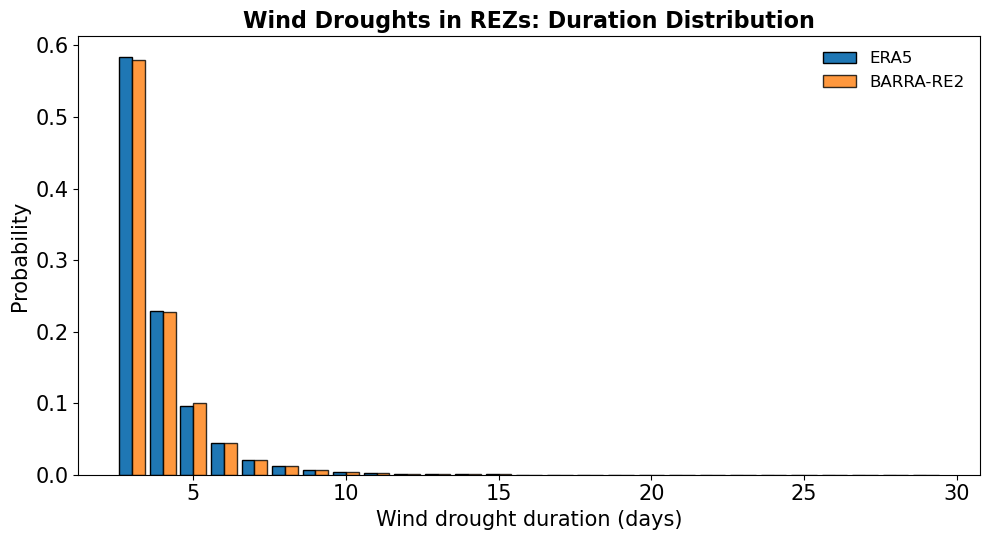

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/REZ_wind_drought_duration_distribution_ERA5_vs_BARRA_RE2.png


In [10]:
plt.figure(
    figsize=(10, 5.5)
)

bar_width = 0.42

plt.bar(
    duration_values - bar_width / 2,
    era5_prob,
    width=bar_width,
    edgecolor="black",
    label="ERA5"
)

plt.bar(
    duration_values + bar_width / 2,
    barra_prob,
    width=bar_width,
    edgecolor="black",
    alpha=0.80,
    label="BARRA-RE2"
)

# x-y tickmarks fontsize
plt.xticks(
    fontsize=15
)
plt.yticks(
    fontsize=15
)

plt.xlabel(
    "Wind drought duration (days)",
    fontsize=15
)

plt.ylabel(
    "Probability",
    fontsize=15
)

plt.title(
    "Wind Droughts in REZs: Duration Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()

out_png = os.path.join(
    output_dir,
    "REZ_wind_drought_duration_distribution_ERA5_vs_BARRA_RE2.png"
)

plt.savefig(
    out_png,
    dpi=300
)

plt.show()

print("Saved:", out_png)


## Note on BARRA-RE2 interpretation

The BARRA-RE2 bars are based on all event durations pooled across the 22 realizations. This means the BARRA-RE2 distribution represents the ensemble event-duration behaviour, not an ensemble-mean binary mask. This is appropriate because event duration must be calculated on binary 0/1 time series.